# CC3092 - Laboratorio 8: entrega parcial

**Task 1:** Mini-GPT a nivel de caracteres sobre Tiny Shakespeare.  
**Task 2:** greedy, top-k y top-p; 25 generaciones y análisis.

> Este notebook reutiliza las ideas del Mini-GPT de la Semana 6, pero adapta el modelo de palabras a caracteres, agrega batches, contexto 128 y tres bloques decoder.

## 1. Configuración

Los hiperparámetros corresponden a los mínimos indicados en el enunciado. El código de la arquitectura y el muestreo está en `lab8_minigpt.py` para poder probarlo sin reentrenar el notebook.

In [1]:
from pathlib import Path
import math
import torch
import matplotlib.pyplot as plt

from lab8_minigpt import (
    MiniGPT, build_corpus, confidence_moments, generate_text,
    load_tiny_shakespeare, run_task2_experiment, save_samples,
    set_seed, summarize_results, train_model,
)

SEED = 42
BLOCK_SIZE = 128
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3
BATCH_SIZE = 64
LEARNING_RATE = 3e-4
EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

set_seed(SEED)
Path('outputs').mkdir(exist_ok=True)
print('Dispositivo:', DEVICE)

Dispositivo: cpu


## 2. Task 1.1 - corpus, vocabulario y batches

El vocabulario se obtiene de los caracteres únicos. La secuencia completa se codifica como enteros y se divide 90/10 respetando el orden temporal. En cada batch, el objetivo `y` es la entrada `x` desplazada un carácter: $y_t=x_{t+1}$. Cada época recorre todos los bloques completos de entrenamiento una vez; se baraja el orden de los bloques, pero nunca el orden interno de los caracteres.

In [2]:
text = load_tiny_shakespeare()
corpus = build_corpus(text)

assert corpus.vocab_size == 65, f'Se esperaban 65 caracteres, se obtuvieron {corpus.vocab_size}'
assert len(corpus.train_data) == int(0.90 * len(text))
assert len(corpus.val_data) == len(text) - len(corpus.train_data)

print(f'Caracteres totales: {len(text):,}')
print(f'Vocabulario: {corpus.vocab_size}')
print(f'Train: {len(corpus.train_data):,} | Validación: {len(corpus.val_data):,}')
print('Vocabulario:', repr(''.join(corpus.stoi.keys())))

Caracteres totales: 1,115,394
Vocabulario: 65
Train: 1,003,854 | Validación: 111,540
Vocabulario: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


## 3. Arquitectura reutilizada y adaptada

Del Proyecto 1 se reutilizan `layer_norm`, las proyecciones $Q=XW_Q$, $K=XW_K$, $V=XW_V$, la atención $\operatorname{softmax}(QK^T/\sqrt{d_k})V$, la máscara causal, los residuales y el feed-forward.

Los cambios necesarios son: tokenización por carácter; tensores `(batch, tiempo, dimensión)`; contexto 128; cuatro cabezas; tres bloques apilados; y una cabeza de lenguaje de 65 logits por posición.

In [3]:
model = MiniGPT(
    vocab_size=corpus.vocab_size,
    block_size=BLOCK_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
).to(DEVICE)

parameter_count = sum(p.numel() for p in model.parameters())
print(f'Parámetros: {parameter_count:,}')

# Verificación de shapes y de máscara causal antes de entrenar.
probe = corpus.train_data[:16].unsqueeze(0).to(DEVICE)
logits, _, attention_maps = model(probe, return_attention=True)
assert logits.shape == (1, 16, 65)
assert len(attention_maps) == N_LAYERS
for weights in attention_maps:
    assert weights.shape == (1, N_HEADS, 16, 16)
    future = torch.triu(weights[0], diagonal=1)
    assert future.abs().max().item() == 0.0
print('Shapes y máscara causal: correctos')

Parámetros: 609,985
Shapes y máscara causal: correctos


## 4. Task 1.2 - entrenamiento y perplejidad

La loss es cross-entropy sobre todos los caracteres objetivo del batch. La validación recorre de forma determinista todos los bloques completos del split, sin muestreo aleatorio, y la perplejidad se calcula como $\exp(\mathcal{L}_{val})$.

In [4]:
history = train_model(
    model,
    corpus,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    checkpoint_path='outputs/training_progress.pt',
    resume=True,
)

final_perplexity = history[-1]['val_perplexity']
print(f'Perplejidad final de validación: {final_perplexity:.3f}')
if not 3.5 <= final_perplexity <= 8.0:
    print('ADVERTENCIA: la perplejidad quedó fuera del rango esperado [3.5, 8.0].')

checkpoint = {
    'model_state': model.state_dict(),
    'stoi': corpus.stoi,
    'itos': corpus.itos,
    'config': {
        'block_size': BLOCK_SIZE, 'd_model': D_MODEL,
        'n_heads': N_HEADS, 'n_layers': N_LAYERS,
    },
    'history': history,
}
torch.save(checkpoint, 'outputs/minigpt_lab8.pt')

Epoch 01/10: train=3.4077, val=3.3513, ppl=28.540


Epoch 02/10: train=3.1755, val=2.8134, ppl=16.667


Epoch 03/10: train=2.6037, val=2.4949, ppl=12.121


Epoch 04/10: train=2.4210, val=2.3755, ppl=10.757


Epoch 05/10: train=2.3376, val=2.3171, ppl=10.146


Epoch 06/10: train=2.2924, val=2.2826, ppl=9.802


Epoch 07/10: train=2.2547, val=2.2557, ppl=9.542


Epoch 08/10: train=2.2178, val=2.2189, ppl=9.197


Epoch 09/10: train=2.1845, val=2.1830, ppl=8.873


Epoch 10/10: train=2.1558, val=2.1570, ppl=8.645
Perplejidad final de validación: 8.645
ADVERTENCIA: la perplejidad quedó fuera del rango esperado [3.5, 8.0].


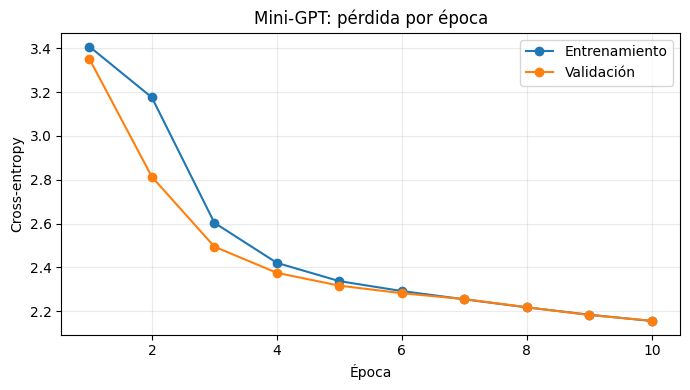

In [5]:
epochs = [row['epoch'] for row in history]
train_losses = [row['train_loss'] for row in history]
val_losses = [row['val_loss'] for row in history]

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, 'o-', label='Entrenamiento')
plt.plot(epochs, val_losses, 'o-', label='Validación')
plt.xlabel('Época')
plt.ylabel('Cross-entropy')
plt.title('Mini-GPT: pérdida por época')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('outputs/loss_curve.png', dpi=150)
plt.show()

## 5. Task 1.3 - funciones de muestreo

Las funciones `sample_greedy`, `sample_top_k` y `sample_top_p` están implementadas desde cero en `lab8_minigpt.py`; cada una recibe logits crudos y retorna únicamente el índice entero del carácter siguiente.

- **Greedy:** $\arg\max_i z_i$.
- **Top-k:** divide logits por $\tau$, conserva los $k$ mayores, aplica softmax y muestrea.
- **Top-p:** aplica temperatura y softmax, ordena probabilidades, conserva el conjunto mínimo cuya masa acumulada alcanza $p$, renormaliza y muestrea.

## 6. Task 2.1 - `generate` y las 25 muestras

La función siguiente conserva exactamente la interfaz pedida. El modelo y el vocabulario entrenados quedan capturados por el notebook; `kwargs` contiene `k`, `p`, `tau` y la opción interna `return_trace`.

In [6]:
def generate(prompt, max_new_tokens, strategy, **kwargs):
    return generate_text(
        model, prompt, max_new_tokens, strategy,
        stoi=corpus.stoi, itos=corpus.itos, **kwargs,
    )

# Prueba corta: la salida debe contener prompt + 20 caracteres nuevos.
smoke = generate('ROMEO: ', 20, 'top-k', k=5, tau=0.7)
assert len(smoke) == len('ROMEO: ') + 20
print(repr(smoke))

'ROMEO: mot the, and met the'


In [7]:
results = run_task2_experiment(
    generate,
    prompt='ROMEO: ',
    samples_per_configuration=5,
    max_new_tokens=200,
)
save_samples(results, 'outputs/task2_samples.txt')

assert set(results) == set('ABCDE')
assert all(len(samples) == 5 for samples in results.values())
assert all(
    len(sample['text']) == len('ROMEO: ') + 200
    for samples in results.values() for sample in samples
)

for configuration, samples in results.items():
    print(f'\n### Configuración {configuration}')
    for index, sample in enumerate(samples, start=1):
        print(f'\n[{configuration}-{index}]\n{sample["text"]}')


### Configuración A

[A-1]
ROMEO: the the the the the the the the the the the
The the the the the the the the the the the the the the
The the the the the the the the the the the the
The the the the the the the the the the the the
The 

[A-2]
ROMEO: the the the the the the the the the the the
The the the the the the the the the the the the the the
The the the the the the the the the the the the
The the the the the the the the the the the the
The 

[A-3]
ROMEO: the the the the the the the the the the the
The the the the the the the the the the the the the the
The the the the the the the the the the the the
The the the the the the the the the the the the
The 

[A-4]
ROMEO: the the the the the the the the the the the
The the the the the the the the the the the the the the
The the the the the the the the the the the the
The the the the the the the the the the the the
The 

[A-5]
ROMEO: the the the the the the the the the the the
The the the the the the the the the the the the the the
The t

## 7. Evidencia cuantitativa para Task 2.2

Además de leer las muestras, calculamos repetición de 4-gramas, entropía, probabilidad máxima y cantidad de candidatos. Estas métricas apoyan el análisis, pero no sustituyen citar ejemplos concretos como `A-1`, `B-3` o `E-1`.

In [8]:
summary = summarize_results(results)
print('config | repetición | entropía | prob. máxima | candidatos')
for row in summary:
    print(
        f"{row['configuration']:^6} | "
        f"{row['mean_repetition_rate']:^10.3f} | "
        f"{row['mean_entropy']:^8.3f} | "
        f"{row['mean_top_probability']:^12.3f} | "
        f"{row['mean_candidate_count']:^10.2f}"
    )

config | repetición | entropía | prob. máxima | candidatos
  A    |   0.954    |  2.126   |    0.382     |    1.00   
  B    |   0.186    |  1.780   |    0.459     |    5.00   
  C    |   0.022    |  2.255   |    0.339     |   50.00   
  D    |   0.224    |  1.807   |    0.450     |    3.99   
  E    |   0.027    |  2.238   |    0.343     |   15.02   


In [9]:
# Configuración E: dos momentos seguros (menor entropía) y dos inciertos
# (mayor entropía). El tamaño del nucleus muestra que top-p es adaptativo.
moments = confidence_moments(results['E'][0], count=2)
for label, rows in moments.items():
    print(f'\n{label.upper()}')
    for row in rows:
        print(
            f"paso={row['step']:3d} char={row['chosen_character']!r} "
            f"Pmax={row['top_probability']:.3f} H={row['entropy']:.3f} "
            f"candidatos={row['candidate_count']:2d} "
            f"contexto={row['context']!r}"
        )


CONFIDENT
paso=195 char='\n' Pmax=0.982 H=0.129 candidatos= 1 contexto='e wave pengas,\nMatt anker, afe loth ines.\n\nLABKET:'
paso= 75 char=' ' Pmax=0.976 H=0.175 candidatos= 1 contexto='y, at brut gre tot fugh fear tearace!\nThy by reip,'

UNCERTAIN
paso=199 char='f' Pmax=0.110 H=3.342 candidatos=37 contexto='ve pengas,\nMatt anker, afe loth ines.\n\nLABKET:\nLo '
paso=  1 char='s' Pmax=0.131 H=3.286 candidatos=35 contexto='ROMEO: '


## 8. Task 2.2 - guía para redactar las respuestas

### a. Configuración A (greedy)
Cite al menos dos muestras A. Greedy elige $i^*=\arg\max_i z_i$ en cada paso; dado el mismo contexto no hay aleatoriedad. Cuando una continuación probable devuelve al modelo a un contexto parecido, vuelve a elegir los mismos máximos y forma un ciclo. Compare esa explicación con la tasa de repetición calculada arriba.

### b. Configuraciones B y C
Cite una muestra B y una C. Pasar de $k=5$ a $k=50$ abre muchas más alternativas. Además, en $P(w_i\mid ctx)=\exp(z_i/\tau)/\sum_j\exp(z_j/\tau)$, subir $\tau$ de 0.7 a 1.0 aplana la distribución. Por ello C normalmente es más diversa/creativa, mientras B suele conservar mayor coherencia local. Confirme la afirmación con sus muestras y métricas; si su corrida contradice esta tendencia, reporte lo observado.

### c. Configuración E
Use las cuatro filas impresas por `confidence_moments`. Menor entropía, mayor probabilidad máxima y pocos candidatos indican seguridad; mayor entropía y un nucleus grande indican incertidumbre. Describa qué carácter o posición aparece: por ejemplo, espacios, saltos de línea y letras después de prefijos muy frecuentes suelen ser más predecibles; el inicio de una palabra o nombre con varias continuaciones puede ser menos seguro. Cite los pasos exactos de su ejecución.